In [2]:
from dotenv import load_dotenv
load_dotenv()
import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits
import sys
sys.path.insert(0, '../src')
#sys.path.insert(0, "/home/gill/apps/szpack/python")
import warnings
import utils as ut
warnings.filterwarnings('ignore')
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
# HFI_FITS = fits.open("/home/gill/Downloads/HFI_RIMO_R3.00.fits")
# LFI_FITS = fits.open("/home/gill/Downloads/LFI_RIMO_R3.31.fits")
# HFI_TABLE = Table.read("/home/gill/Downloads/HFI_RIMO_R3.00.fits", hdu=1)
# # Convert wavenumber to frequency in GHz
# # wavenumber is in cm^-1, need to convert to Hz then GHz
# # frequency = wavenumber * c (speed of light in cm/s)

# wavenumber = LFI_FITS[14].data['WAVENUMBER']  # in cm^-1
# transmission = LFI_FITS[14].data['TRANSMISSION']  # transmission values
# c_cm_per_s = 2.998e10  # speed of light in cm/s
# frequency_hz = wavenumber * c_cm_per_s
# frequency_ghz = frequency_hz / 1e9  # convert Hz to GHz

# plt.figure(figsize=(10, 6))
# plt.plot(wavenumber, transmission)
# plt.xlabel('Frequency (GHz)')
# plt.ylabel('Transmission')
# plt.title('HFI Transmission vs Frequency')
# plt.grid(True)
# plt.show()

In [4]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.size": 25,
    "axes.labelsize": 25,
    "axes.titlesize": 25,
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 20,
})

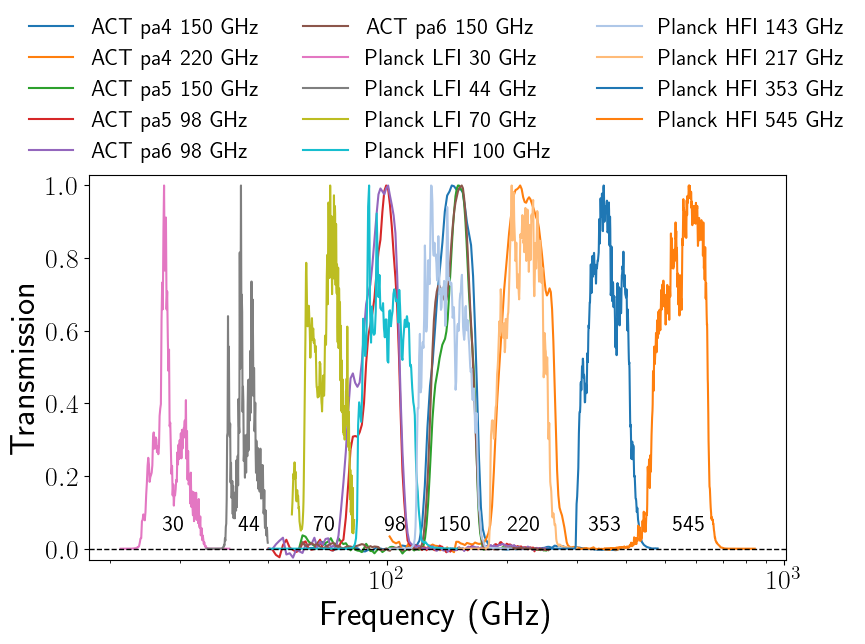

In [ ]:
# # latex rendering
# cf = ut.get_config_file("../configs/case10_ajay.yaml")

# plt.figure(figsize=(9, 5)) 

# # Define a color palette with enough distinct colors
# colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78']

# for i, data in enumerate(cf["data"]):
#     freq = data.split('_')[0]
#     array = data.split('_')[1]
#     inst = data.split('_')[2]
#     scan = data.split('_')[3]

#     freq_str = ut.get_freq_str(frequency=freq)
#     x_array, freq_array, del_freq = ut.get_freq_bandpass(array=array, freq_str=freq_str)
#     bandpass, bandpass_int = ut.get_bandpass(array=array, freq_str=freq_str)

#     # normalize bandpass
#     bandpass /= np.max(bandpass)

#     if freq == "98":
#         freq = "98"
    
#     if "pa" in array: 
#         label = f"ACT {array} {freq} GHz"
#         linestyle = '-'
#     elif int(freq) < 100:
#         label = f"Planck LFI {freq} GHz"
#         linestyle = 'solid'
#     else:
#         label = f"Planck HFI {freq} GHz"
#         linestyle = 'solid'

#     # Use modulo to cycle through colors without repetition until we run out
#     color = colors[i % len(colors)]
#     plt.semilogx(freq_array, bandpass, label=label, color=color, linestyle=linestyle)

# plt.xlabel('Frequency (GHz)')
# plt.ylabel('Transmission')
# plt.axhline(0, color='black', lw=1, ls='--')
# plt.legend(bbox_to_anchor=(0.5, 0.98), loc='lower center', ncol=3, frameon=False, fontsize=16)

# plt.text(27, 0.05, "30", fontsize=16, color='black')
# plt.text(42, 0.05, "44", fontsize=16, color='black')
# plt.text(65, 0.05, "70", fontsize=16, color='black')
# plt.text(98, 0.05, "98", fontsize=16, color='black')
# plt.text(135, 0.05, "150", fontsize=16, color='black')
# plt.text(200, 0.05, "220", fontsize=16, color='black')
# plt.text(320, 0.05, "353", fontsize=16, color='black')
# plt.text(520, 0.05, "545", fontsize=16, color='black')
# plt.ylim(-0.03, 1.03)
# plt.savefig("../plots/bandpasses.pdf", bbox_inches='tight', dpi=500)
# plt.show()


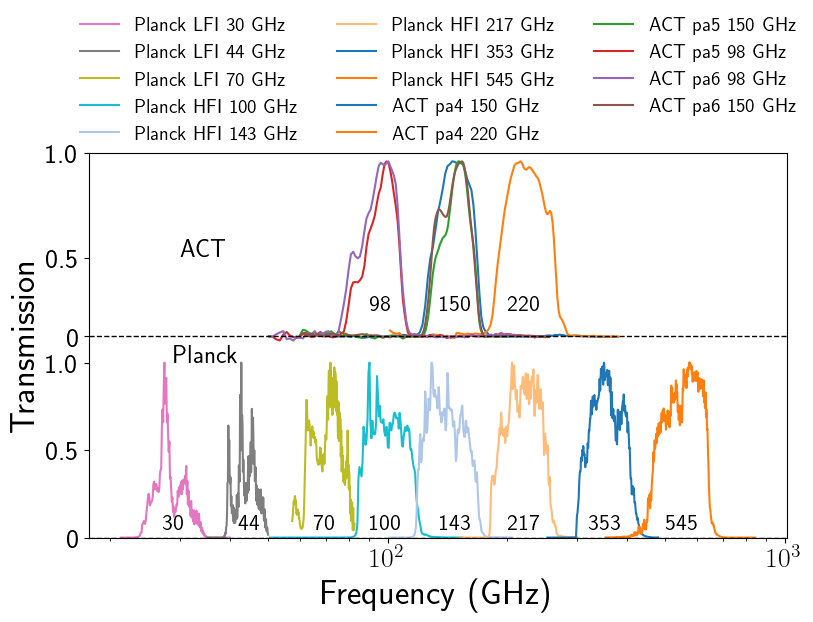

In [51]:
# latex rendering
cf = ut.get_config_file("../configs/case10_ajay.yaml")

plt.figure(figsize=(9, 5)) 

# Define a color palette with enough distinct colors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd', '#8c564b', '#e377c2', '#7f7f7f', '#bcbd22', '#17becf', '#aec7e8', '#ffbb78']

# Separate ACT and Planck data
act_data = []
planck_data = []

for i, data in enumerate(cf["data"]):
    freq = data.split('_')[0]
    array = data.split('_')[1]
    inst = data.split('_')[2]
    scan = data.split('_')[3]

    freq_str = ut.get_freq_str(frequency=freq)
    x_array, freq_array, del_freq = ut.get_freq_bandpass(array=array, freq_str=freq_str)
    bandpass, bandpass_int = ut.get_bandpass(array=array, freq_str=freq_str)

    # normalize bandpass
    bandpass /= np.max(bandpass)

    if freq == "98":
        freq = "98"
    
    if "pa" in array: 
        label = f"ACT {array} {freq} GHz"
        linestyle = '-'
        act_data.append((freq_array, bandpass, label, colors[i % len(colors)], linestyle))
    elif int(freq) < 100:
        label = f"Planck LFI {freq} GHz"
        linestyle = 'solid'
        planck_data.append((freq_array, bandpass, label, colors[i % len(colors)], linestyle))
    else:
        label = f"Planck HFI {freq} GHz"
        linestyle = 'solid'
        planck_data.append((freq_array, bandpass, label, colors[i % len(colors)], linestyle))

# Plot Planck data (offset to 0-1 range)
for freq_array, bandpass, label, color, linestyle in planck_data:
    plt.semilogx(freq_array, bandpass, label=label, color=color, linestyle=linestyle)

# Plot ACT data (offset to 1.1-2.1 range)
for freq_array, bandpass, label, color, linestyle in act_data:
    plt.semilogx(freq_array, bandpass + 1.15, label=label, color=color, linestyle=linestyle)

plt.xlabel('Frequency (GHz)')
plt.ylabel('Transmission')
plt.axhline(0, color='black', lw=1, ls='--')
plt.axhline(1.15, color='black', lw=1, ls='--')

# Set custom y-ticks and labels
yticks = [0, 0.5, 1.0, 1.15, 1.6, 2.2]
ylabels = ['0', '0.5', '1.0', '0', '0.5', '1.0']
plt.yticks(yticks, ylabels)

plt.legend(bbox_to_anchor=(0.5, 0.98), loc='lower center', ncol=3, frameon=False, fontsize=14)

# Add frequency labels for Planck
plt.text(27, 0.05, "30", fontsize=16, color='black')
plt.text(42, 0.05, "44", fontsize=16, color='black')
plt.text(65, 0.05, "70", fontsize=16, color='black')
plt.text(90, 0.05, "100", fontsize=16, color='black')
plt.text(135, 0.05, "143", fontsize=16, color='black')
plt.text(200, 0.05, "217", fontsize=16, color='black')
plt.text(320, 0.05, "353", fontsize=16, color='black')
plt.text(500, 0.05, "545", fontsize=16, color='black')

# add text for ACT
plt.text(90, 1.3, "98", fontsize=16, color='black')
plt.text(135, 1.3, "150", fontsize=16, color='black')
plt.text(200, 1.3, "220", fontsize=16, color='black')

# Add labels for the two sections
plt.text(29, 1, "Planck", fontsize=18, color='black', weight='bold')
plt.text(30, 1.6, "ACT", fontsize=18, color='black', weight='bold')

plt.ylim(0, 2.2)
plt.savefig("../plots/bandpasses_aug25.pdf", bbox_inches='tight', dpi=500)
plt.show()
